# **Bitcoin Price Prediction using LSTM Deep Learning (Financial Forecasting Intelligence System)**

### **Project Objective**

The objective of this project is to develop a **Financial Time-Series Forecasting System** using **Long Short-Term Memory (LSTM) Neural Networks** to predict future Bitcoin prices based on historical market data.

Cryptocurrency markets are highly volatile and complex, making accurate prediction a challenging task. This project focuses on leveraging deep learning techniques to capture temporal dependencies and trends in Bitcoin price movements.

The system is designed to:

- Predict **future Bitcoin prices**  
- Capture **temporal dependencies in financial data**  
- Learn **market trends and volatility patterns**  
- Demonstrate the effectiveness of **LSTM networks for financial forecasting**  

This project is highly applicable in:
- algorithmic trading  
- financial analytics  
- investment decision-making  
- cryptocurrency market analysis  

### **Dataset Used**

This project utilizes financial time-series datasets containing historical Bitcoin price data.

### **Dataset Sources**

- **Bitcoin Historical Price Dataset** *(e.g., from Kaggle, Yahoo Finance, or dataset used in your notebook)*  

### **Dataset Characteristics**

The dataset includes:

- **Time index**:
  - daily or hourly timestamps  

- **Features**:
  - open, high, low, close prices  
  - trading volume  

Key characteristics:
- multivariate time-series data  
- high volatility  
- non-linear patterns  

### **How Dataset is Used in the Project**

The dataset is processed through a financial forecasting pipeline:

- **Data preprocessing**
  - normalization / scaling  
  - handling missing values  

- **Feature selection**
  - selecting relevant price indicators  

- **Sequence generation**
  - converting time-series into supervised learning format  

- **Train-test split**
  - temporal split  

- **Model training**
  - LSTM learns sequential dependencies  
  - predicts future price  

The dataset enables the model to learn **market patterns and trends**, which are essential for prediction.




### **Import Libraries:**

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Libraries imported successfully.")


Libraries imported successfully.


### **Download BTC-USD Data:**

In [2]:
df = yf.download("BTC-USD", start="2018-01-01", end="2025-01-01", auto_adjust=False)
df.head()


[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,,
2018-01-01,13657.200195,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
2018-01-02,14982.099609,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2018-01-03,15201.000000,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
2018-01-04,15599.200195,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
2018-01-05,17429.500000,17429.500000,17705.199219,15202.799805,15477.200195,23840899072


### **Inspect Dataset:**

In [3]:
print("Shape:", df.shape)
print(df.info())


Shape: (2557, 6)
<class 'pandas.DataFrame'>
DatetimeIndex: 2557 entries, 2018-01-01 to 2024-12-31
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   (Adj Close, BTC-USD)  2557 non-null   float64
 1   (Close, BTC-USD)      2557 non-null   float64
 2   (High, BTC-USD)       2557 non-null   float64
 3   (Low, BTC-USD)        2557 non-null   float64
 4   (Open, BTC-USD)       2557 non-null   float64
 5   (Volume, BTC-USD)     2557 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 139.8 KB
None


### **Reset Index and Select Relevant Features:**

In [4]:
df = df.reset_index()
df = df[["Date", "Open", "High", "Low", "Close", "Volume"]].dropna().reset_index(drop=True)
df.head()


Price,Date,Open,High,Low,Close,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
0,2018-01-01,14112.200195,14112.200195,13154.700195,13657.200195,10291200000
1,2018-01-02,13625.000000,15444.599609,13163.599609,14982.099609,16846600192
2,2018-01-03,14978.200195,15572.799805,14844.500000,15201.000000,16871900160
3,2018-01-04,15270.700195,15739.700195,14522.200195,15599.200195,21783199744
4,2018-01-05,15477.200195,17705.199219,15202.799805,17429.500000,23840899072


### **Plot Closing Price:**

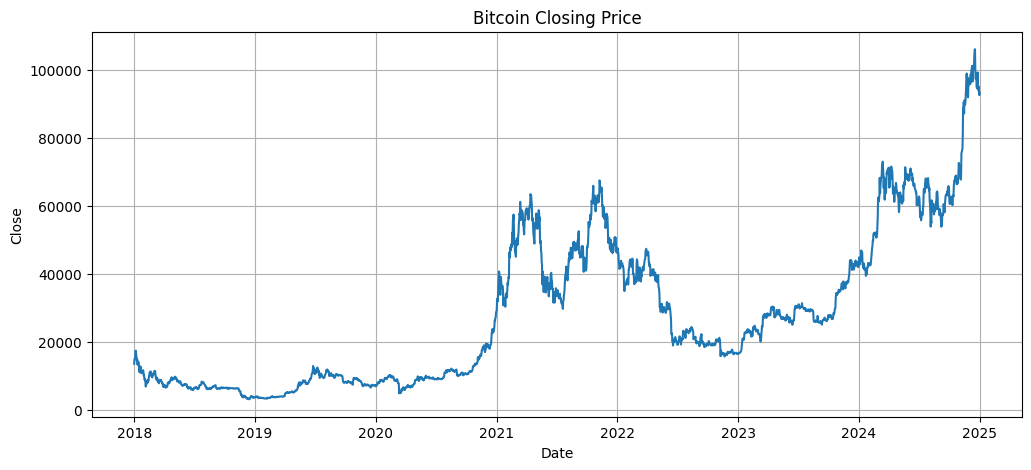

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Close"])
plt.title("Bitcoin Closing Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.show()


### **Create Technical Features:**

In [6]:
df["SMA_7"] = df["Close"].rolling(7).mean()
df["SMA_30"] = df["Close"].rolling(30).mean()
df["Return"] = df["Close"].pct_change()
df = df.dropna().reset_index(drop=True)
df.head()


Price,Date,Open,High,Low,Close,Volume,SMA_7,SMA_30,Return
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,
0,2018-01-30,11306.799805,11307.200195,10036.200195,10106.299805,8637859840,11202.843052,13181.040039,-0.105352
1,2018-01-31,10108.200195,10381.599609,9777.419922,10221.099609,8041160192,11040.228655,13066.503353,0.011359
2,2018-02-01,10237.299805,10288.799805,8812.280273,9170.540039,9959400448,10741.820033,12872.784701,-0.102783
3,2018-02-02,9142.280273,9142.280273,7796.490234,8830.750000,12726899712,10407.441406,12660.443034,-0.037052
4,2018-02-03,8852.120117,9430.750000,8251.629883,9174.910156,7263790080,10083.757115,12446.300033,0.038973


### **Visualize Rolling Averages:**

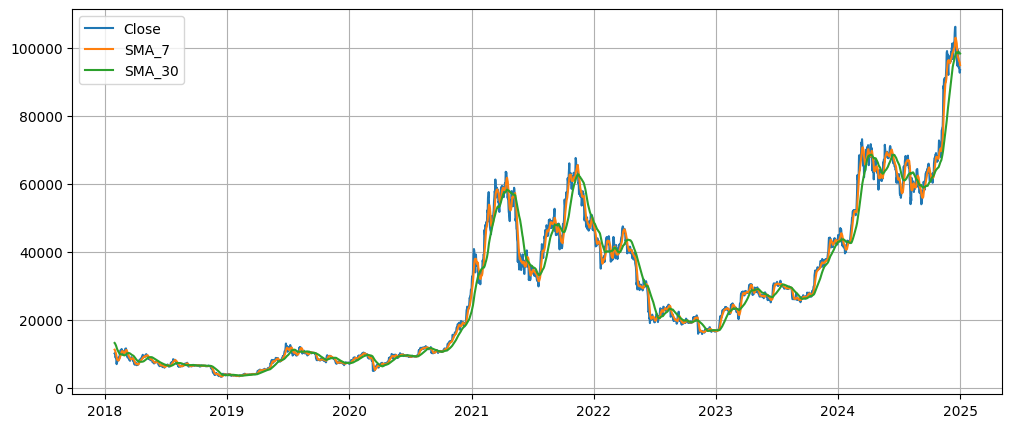

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["SMA_7"], label="SMA_7")
plt.plot(df["Date"], df["SMA_30"], label="SMA_30")
plt.legend()
plt.grid(True)
plt.show()


### **Select Model Features:**

In [8]:
feature_cols = ["Close", "SMA_7", "SMA_30", "Return", "Volume"]
data = df[feature_cols].copy()
data.head()


Price,Close,SMA_7,SMA_30,Return,Volume
Ticker,BTC-USD,,,,BTC-USD
0,10106.299805,11202.843052,13181.040039,-0.105352,8637859840
1,10221.099609,11040.228655,13066.503353,0.011359,8041160192
2,9170.540039,10741.820033,12872.784701,-0.102783,9959400448
3,8830.750000,10407.441406,12660.443034,-0.037052,12726899712
4,9174.910156,10083.757115,12446.300033,0.038973,7263790080


### **Scale Features:**

In [9]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
scaled_data[:3]


array([[0.06675687, 0.07884566, 0.1010193 , 0.47632722, 0.016418  ],
       [0.06787247, 0.07721265, 0.09981566, 0.68505353, 0.01470356],
       [0.05766333, 0.07421597, 0.09777993, 0.48092122, 0.02021504]])

### **Define Sequence Builder:**

In [10]:
def create_btc_sequences(data, look_back=30, target_col_index=0):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back, target_col_index])
    return np.array(X), np.array(y)


### **Define Search Space:**

In [11]:
search_space = [
    {"look_back": 30, "units_1": 64, "units_2": 32, "dropout": 0.2, "batch_size": 32},
    {"look_back": 45, "units_1": 64, "units_2": 32, "dropout": 0.3, "batch_size": 32},
    {"look_back": 30, "units_1": 128, "units_2": 32, "dropout": 0.2, "batch_size": 16}
]


### **Define Model Builder:**

In [12]:
def build_btc_lstm(input_shape, units_1=64, units_2=32, dropout=0.2):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units_1, return_sequences=True),
        Dropout(dropout),
        LSTM(units_2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


### **Initialize Tuning Variables:**

In [13]:
best_config = None
best_val_rmse = np.inf


In [14]:
### **Run Manual Hyperparameter Tuning:**

In [15]:
for config in search_space:
    X_all, y_all = create_btc_sequences(scaled_data, look_back=config["look_back"], target_col_index=0)
    split_index = int(len(X_all) * 0.8)
    X_train, X_val = X_all[:split_index], X_all[split_index:]
    y_train, y_val = y_all[:split_index], y_all[split_index:]

    temp_model = build_btc_lstm(
        input_shape=(config["look_back"], X_all.shape[2]),
        units_1=config["units_1"],
        units_2=config["units_2"],
        dropout=config["dropout"]
    )

    temp_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=config["batch_size"], verbose=0)
    val_pred = temp_model.predict(X_val, verbose=0)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    print(config, "-> Validation RMSE:", round(val_rmse, 4))

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_config = config

print("Best config:", best_config)
print("Best validation RMSE:", round(best_val_rmse, 4))


{'look_back': 30, 'units_1': 64, 'units_2': 32, 'dropout': 0.2, 'batch_size': 32} -> Validation RMSE: 0.035
{'look_back': 45, 'units_1': 64, 'units_2': 32, 'dropout': 0.3, 'batch_size': 32} -> Validation RMSE: 0.0562
{'look_back': 30, 'units_1': 128, 'units_2': 32, 'dropout': 0.2, 'batch_size': 16} -> Validation RMSE: 0.0266
Best config: {'look_back': 30, 'units_1': 128, 'units_2': 32, 'dropout': 0.2, 'batch_size': 16}
Best validation RMSE: 0.0266


### **Prepare Final Sequences:**

In [16]:
look_back = best_config["look_back"]
X_all, y_all = create_btc_sequences(scaled_data, look_back=look_back, target_col_index=0)
split_index = int(len(X_all) * 0.8)
X_train, X_test = X_all[:split_index], X_all[split_index:]
y_train, y_test = y_all[:split_index], y_all[split_index:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


X_train: (1998, 30, 5)
X_test : (500, 30, 5)


### **Build Final Model:**

In [17]:
model = build_btc_lstm(
    input_shape=(look_back, X_all.shape[2]),
    units_1=best_config["units_1"],
    units_2=best_config["units_2"],
    dropout=best_config["dropout"]
)
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 30, 128)             │          68,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 30, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 32)                  │          20,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 90,305 (352.75 KB)

 Trainable params: 90,305 (352.75 KB)

 Non-trainable params: 0 (0.00 B)

### **Configure Callbacks:**

In [18]:
early_stopping = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)


### **Train Final Model:**

In [19]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=best_config["batch_size"],
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0021 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 2/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 7.1346e-04 - val_loss: 0.0063 - learning_rate: 0.0010
Epoch 3/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5.7110e-04 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 4/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.9081e-04 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 5/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.8504e-04 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 6/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 3.2631e-04 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 7/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.9115e-04 - val_loss: 0.0022 - learning_rate: 5.0000e-04
Epoch 8/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 2.6523e-04 - val_loss: 0.0012 - learning_rate: 5.0000e-04
Epoch 9/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.6574e-04 - va

### **Plot Loss Curves:**

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.grid(True)
plt.show()


### **Predict on Test Set:**

In [20]:
test_pred = model.predict(X_test, verbose=0)


### **Inverse Transform Predictions:**

In [21]:
def inverse_first_col(pred_array, n_features, scaler_obj):
    temp = np.zeros((len(pred_array), n_features))
    temp[:, 0] = pred_array.flatten()
    return scaler_obj.inverse_transform(temp)[:, 0]

y_test_inv = inverse_first_col(y_test.reshape(-1, 1), X_all.shape[2], scaler)
y_pred_inv = inverse_first_col(test_pred, X_all.shape[2], scaler)


### **Evaluate Metrics:**

In [22]:
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print("RMSE:", round(rmse, 4))
print("MAE :", round(mae, 4))
print("R2  :", round(r2, 4))


RMSE: 2426.9979
MAE : 1651.0163
R2  : 0.9845


### **Plot Actual vs Predicted:**

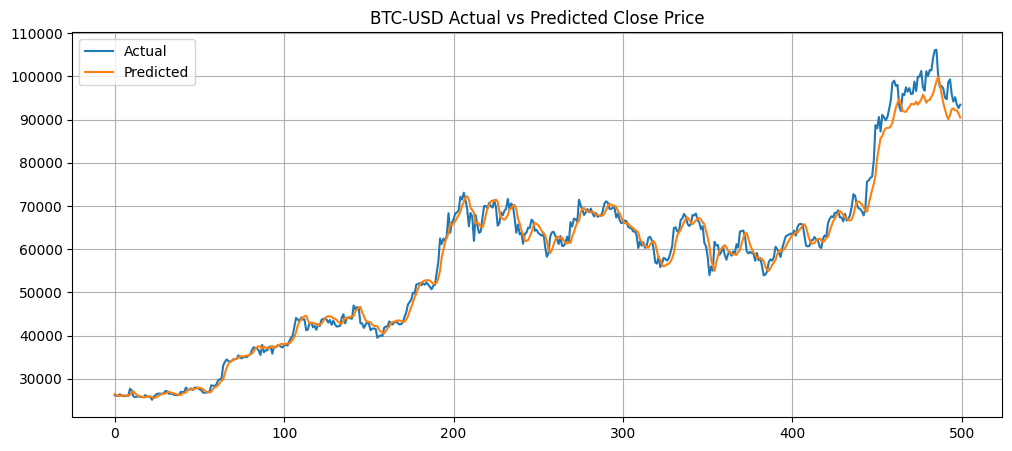

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_inv, label="Actual")
plt.plot(y_pred_inv, label="Predicted")
plt.title("BTC-USD Actual vs Predicted Close Price")
plt.legend()
plt.grid(True)
plt.show()


### **Forecast Next 10 Days:**

In [24]:
def forecast_btc(model, recent_window, n_steps, scaler_obj):
    preds = []
    current = recent_window.copy()
    for _ in range(n_steps):
        pred_scaled = model.predict(current.reshape(1, current.shape[0], current.shape[1]), verbose=0)[0][0]
        preds.append(pred_scaled)
        next_row = current[-1].copy()
        next_row[0] = pred_scaled
        current = np.vstack([current[1:], next_row])
    return inverse_first_col(np.array(preds).reshape(-1, 1), recent_window.shape[1], scaler_obj)

future_btc = forecast_btc(model, X_all[-1], 10, scaler)
future_btc


array([90450.4551786 , 89116.97303157, 87642.06969552, 86207.73363814,
       84911.0221043 , 83816.25146596, 82941.1047386 , 82288.18254608,
       81827.9457269 , 81547.63037014])

### **Save Model and Artifacts:**

In [25]:
model.save("bitcoin_lstm_model.h5")
with open("bitcoin_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("bitcoin_best_config.pkl", "wb") as f:
    pickle.dump(best_config, f)
print("Artifacts saved successfully.")


Artifacts saved successfully.


### **Reload Artifacts:**

In [26]:
from tensorflow.keras.models import load_model
import pickle

# Load model without restoring legacy compile config
reloaded_model = load_model("bitcoin_lstm_model.h5", compile=False)

# Compile again manually with safe names
reloaded_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

with open("bitcoin_scaler.pkl", "rb") as f:
    scaler_loaded = pickle.load(f)

print("Reloaded artifacts successfully.")


Reloaded artifacts successfully.


### **Predict on Small Batch with Reloaded Model:**

In [27]:
reload_preds = reloaded_model.predict(X_test[:5], verbose=0)
print(reload_preds.flatten())


[0.22610193 0.22360383 0.22225374 0.22143182 0.2228735 ]


### **Project Summary**

This project presents a complete implementation of a **Bitcoin Price Prediction System using LSTM Neural Networks**, focusing on forecasting cryptocurrency prices.

The workflow begins with preprocessing financial data, including normalization and sequence preparation.

The core of the system is an **LSTM-based Deep Learning Model**, which consists of:

### **1. Sequence Input Layer**

- Converts historical price data into sequences  

### **2. LSTM Layers**

- Capture long-term dependencies  
- Learn temporal patterns in price movements  

### **3. Dense Output Layer**

- Predicts future price values  

The model learns:
- price trends  
- volatility patterns  
- temporal dependencies  

A key strength of this project is:

- **Financial time-series modeling**
  - handles complex market behavior  

- **Deep learning approach**
  - captures non-linear patterns  

Evaluation is performed using:

- Mean Squared Error (MSE)  
- Root Mean Squared Error (RMSE)  

The system can be used in real-world applications to:

- support trading strategies  
- analyze market trends  
- assist in investment decisions  

Overall, this project demonstrates strong AI capabilities and showcases the ability to build **financial forecasting systems using deep learning**.

### **Key Highlights**

- Built a **Bitcoin Price Prediction system using LSTM**, targeting financial AI applications.

- Addressed complex problem:
  - predicting cryptocurrency prices  

- Utilized dataset with:
  - financial time-series data  

- Implemented a complete **data preprocessing pipeline**, including:
  - normalization  
  - sequence generation  

- Leveraged **LSTM neural networks**, enabling:
  - modeling of temporal dependencies  

- Designed a **forecasting system**, enabling:
  - prediction of future prices  

- Developed a **financial prediction model**, capable of:
  - capturing volatility and trends  

- Evaluated model performance using:
  - MSE, RMSE  

- Enabled **real-world applications**, including:
  - algorithmic trading  
  - financial analysis  
  - investment decision support  

- Designed for **deployment scenarios**, including:
  - trading dashboards  
  - financial analytics platforms  

- Demonstrates strong expertise in:
  - **time-series forecasting**  
  - **deep learning (LSTM)**  
  - **financial machine learning**